# Do Games Actually Move the Market?
### Critical Reception, Sales, and Publisher Stock Performance Around Launch Windows

---
## Contents
1. [Introduction](#1-introduction)
2. [Hypothesis](#2-hypothesis)
3. [Data Sources & Methodology](#3-data-sources--methodology)
4. [Environment Setup](#4-environment-setup)
5. [Data Collection](#5-data-collection)
    - [i. Games](#i-games)
    - [ii. Stock Dataset](#ii-stock-dataset)
6. [Data Cleaning](#6-data-cleaning)
7. [Exploratory Analysis](#7-exploratory-analysis)
    - [i. Score Distribution](#i-score-distribution)
    - [ii. Score vs Stock Return](#ii-score-vs-stock-return)
    - [iii. Returns by Score Tier](#iii-returns-by-score-tier)
8. [Findings](#8-findings)
9. [Limitations](#9-limitations)

---
## 1. Introduction

The games industry generated over $180 bllion in revenue in 2023 - larger than film and music combined. Yet despite its scale, the relationship between individual game performance and publisher stock price remains poorly understood outside of specialist analysts.

This notebook investigates whether measurable game performance indicators - critic review scores and sales figures - correlate with short-term abnormal movement in publisher stock prices.

The publishers under analysis are **Electronic Arts (EA)**, **Activision Blizzard (ATVI)**, and **Ubisoft (UBI.PA)** - three of the largest Western publishers with consistent release histories and publicly traded stock across the period of interest.

---
## 2. Hypothesis

I propose two related hypotheses:

**H1: Review scores:** Games with significantly above-average Metacritic scores (≥ 85) will correlate 
with positive abnormal stock returns in the ±7 day window around launch. Critically reviewed flops 
(≤ 50) will correlate with negative movement.

**H2: Sales performance:** Titles that outperform sales expectations relative to franchise history 
will produce stronger positive returns than review scores alone.

**Expected complication:** For heavily anticipated titles with large marketing spend - think a mainline 
FIFA, Call of Duty, or Assassin's Creed - I expect the market to have already priced in expected 
performance, dampening the post-launch signal. This is the *efficient market hypothesis* applied to 
game launches, and testing whether it holds is part of what makes this interesting.

---
## 3. Data Sources and Methodology

**Game data:** Metacritic scores and release dates sourced from the RAWG Video Games Database API 
(free tier, no scraping required). Filtered to EA, Activision Blizzard, and Ubisoft titles released 
between 2012–2023.

**Sales data:** Where available, pulled from public VGChartz records via a cleaned community dataset. 
Sales figures are estimates and treated as directional rather than precise.

**Stock data:** Daily adjusted closing prices fetched via `yfinance` for EA (`EA`), 
Activision Blizzard (`ATVI`), and Ubisoft (`UBI.PA`) across the same period.

**Event window:** I define launch impact as the stock return across a **±7 day window** centred on 
release date. This is a simplified event study - in academic finance, abnormal returns are typically 
benchmarked against a market index, but for exploratory analysis we use raw return as a readable proxy.

**Limitations acknowledged upfront:** Sales data has gaps. Metacritic scores reflect critic consensus, 
not audience reception (which can diverge sharply). Market movements are noisy and multi-causal - 
a good game launch can coincide with a bad earnings report. This analysis is exploratory, not causal.

---
## 4. Environment Setup

Libraries used:
* `requests` for API calls
* `pandas` and `numpy` for data manipulation
* `matplotlib` and `seaborn` for visualisation
* `yfinance` for stock data
* `python-dotenv`to load the API key from a local `.env` file.

In [2]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
RAWG_API_KEY = os.getenv("RAWG_API_KEY")

---
## 5. Data Collection

First, I pulled game data from the RAWG API, querying by publisher slug and filtering for titles 
with Metacritic scores. Each publisher is fetched across multiple pages to build a representative 
sample. Then, I pulled adjusted daily closing prices for each corresponding stock ticker via yfinance.

The two datasets are not directly joinable by a shared key - they are linked by publisher identity 
and date proximity. The join happens at the event window calculation stage.

In [28]:
def fetch_games(publisher, api_key, pages=5):
    games = []

    for page in range(1, pages + 1):
        url = "https://api.rawg.io/api/games"
        params = {
            "key": api_key,
            "publishers": publisher,
            "page": page,
            "page_size": 40,
            "metacritic": "1,100",
            "ordering": "-metacritic"
        }

        response = requests.get(url, params=params)
        data = response.json()
        for game in data.get("results", []):
            games.append({
                "title": game["name"],
                "release_date": game["released"],
                "metacritic": game["metacritic"],
                "publisher": publisher
            })
        time.sleep(0.3)
    return games

publishers = {
    "electronic-arts": "EA",
    "rockstar-games": "TTWO",
    "2k-games": "TTWO",
    "ubisoft-entertainment": "UBI.PA"
}

all_games = []
for slug, ticker in publishers.items():
    games = fetch_games(slug, RAWG_API_KEY)

    for g in games:
        g["ticker"] = ticker
    all_games.extend(games)

df_games = pd.DataFrame(all_games)
df_games["release_date"] = pd.to_datetime(df_games["release_date"])
df_games = df_games.dropna(subset=["metacritic", "release_date"])
df_games = df_games[(df_games["release_date"] >= "2013-01-01") & 
                    (df_games["release_date"] <= "2025-12-31")]

print(df_games.shape)
df_games.head()

(171, 5)


,title,release_date,metacritic,publisher,ticker
29,It Takes Two,2021-03-26,88,electronic-arts,EA
33,Battlefield 1,2016-10-21,88,electronic-arts,EA
34,Mass Effect: Legendary Edition,2021-05-14,88,electronic-arts,EA
41,Titanfall 2,2016-10-28,87,electronic-arts,EA
47,Dragon Age: Inquisition,2014-11-18,86,electronic-arts,EA


### 5a. Games Dataset

The above shows the raw games dataframe before cleaning. Each row is a title with its release date, 
Metacritic score, publisher, and corresponding stock ticker. Note any nulls or date anomalies, as these will be addressed in the cleaning step.

In [29]:
import yfinance as yf

tickers = ["EA", "TTWO", "UBI.PA"]
stock_data = {}

df_stocks = yf.download(tickers, start="2012-06-01", end="2025-12-31", auto_adjust=True)["Close"]
df_stocks.index = pd.to_datetime(df_stocks.index)
df_stocks.head()

[*********************100%***********************]  3 of 3 completed


Ticker,EA,TTWO,UBI.PA
2012-06-01,12.744438,11.06,5.279
2012-06-04,12.695868,10.90,5.084
2012-06-05,12.763864,11.14,5.303
2012-06-06,13.317550,11.63,5.411
2012-06-07,13.035850,11.14,5.520


### 5b. Stock Dataset

Daily adjusted closing prices across the full date range for all three tickers. Ubisoft (`UBI.PA`) trades on Euronext Paris - price is in EUR, which is worth noting when comparing absolute values across publishers, though percentage returns remain comparable.

---
## 6. Data Cleaning

Before analysis, I made the following cleaning decisions explicit:

- Drop any game with a null Metacritic score - unreviewed title would skew the distribution
- Drop any game where a valid stock price cannot be found within the event window - likely delisted periods or data gaps
- Restrict date range to 2013-2025 for consistency across all three tickers
- Remove duplicate titles where the same game appears under multiple regional entries

The shape of the data before and after cleaning is printed below

In [25]:
def get_event_return(ticker, release_date, stock_df, window=7):
    try:
        prices = stock_df[ticker].dropna()
        before = prices[prices.index <= release_date].iloc[-window:]
        after = prices[prices.index >= release_date].iloc[:window]

        if before.empty or after.empty:
            return None
        
        price_before = before.iloc[0]
        price_after = after.iloc[-1]

        return (price_after - price_before) / price_before * 100
    except:
        return None
    
df_games["event_return"] = df_games.apply(lambda row: get_event_return(row["ticker"], row["release_date"], df_stocks),
    axis=1
)

df_games = df_games.dropna(subset=["event_return"])
df_games.head()

,title,release_date,metacritic,publisher,ticker,event_return
29,It Takes Two,2021-03-26,88,electronic-arts,EA,10.374979
33,Battlefield 1,2016-10-21,88,electronic-arts,EA,-3.962790
34,Mass Effect: Legendary Edition,2021-05-14,88,electronic-arts,EA,0.530659
41,Titanfall 2,2016-10-28,87,electronic-arts,EA,-1.745004
47,Dragon Age: Inquisition,2014-11-18,86,electronic-arts,EA,5.865255


---
## 7. Exploratory Analysis

Now, I have a joined dataset with the Metacritic scores and corresponding ±7 day stock returns for each title. The following sections explore three questions:

1. How are review scores distributed across publishers?
2. Is there a visible relationship between score and stock return?
3. Does grouping by score tier (flop / mid / hit) reveal a pattern in average returns?

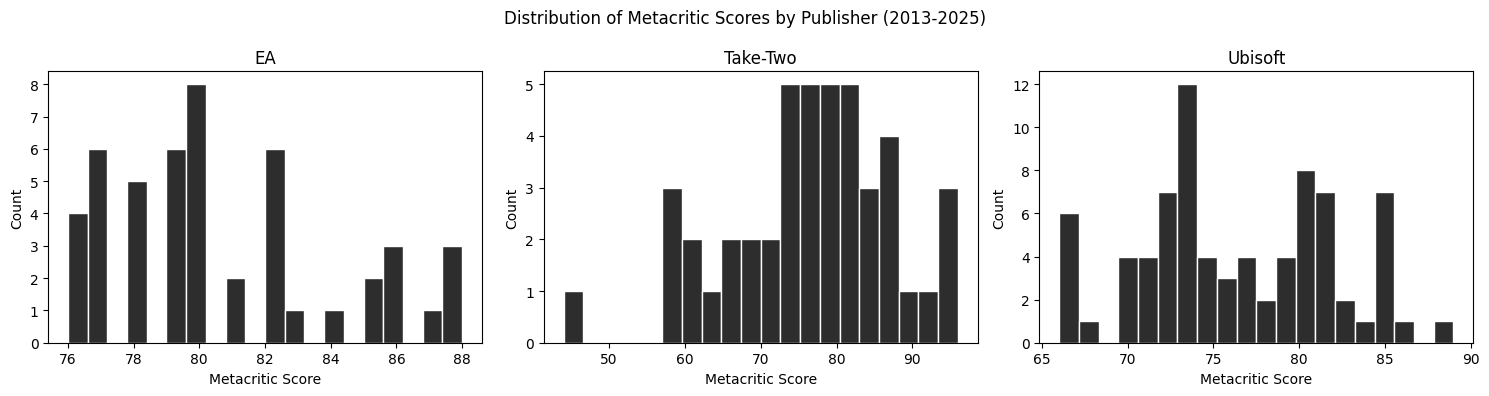

In [30]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

for ax, (publisher, ticker) in zip(axes, [("EA", "EA"), ("Take-Two", "TTWO"), ("Ubisoft", "UBI.PA")]):
    subset = df_games[df_games["ticker"] == ticker] 
    
    ax.hist(subset["metacritic"], bins = 20, color = "#2d2d2d", edgecolor="white")
    ax.set_title(publisher)
    ax.set_xlabel("Metacritic Score")
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Metacritic Scores by Publisher (2013-2025)")
plt.tight_layout()
plt.savefig("figures/score_distribution.png", dpi=150)
plt.show()

918 ubisoft-entertainment Ubisoft Entertainment
53322 ubisoft-divertissements-inc UBISOFT DIVERTISSEMENTS
75433 uisoft UIsoft
12484 ultisoft Ultisoft
10131 bitsoft-inc BITSOFT
